# 11 - Role Intelligence

Day 3, step 11. `occupation_data.csv` becomes the role master table. No ML - this is
reference data.

The point is to remove ambiguity: once every role has a stable O*NET code, "Research
Scientist requires Python, R, SAS" is a statement about a specific, defined
occupation rather than about a job title someone typed into a spreadsheet.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.utils.config import DOCS_DIR, PROCESSED_FILES

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 90)

occupations = pd.read_csv(PROCESSED_FILES["occupation"])
employees = pd.read_csv(PROCESSED_FILES["attrition"])
requirements = pd.read_csv(PROCESSED_FILES["role_requirements"])
mapping = pd.read_csv(DOCS_DIR / "role_to_onet_mapping.csv")

print(f"O*NET occupations available : {len(occupations):,}")
print(f"IBM job roles in use        : {employees['JobRole'].nunique()}")

O*NET occupations available : 1,016
IBM job roles in use        : 9


## The mapping, and why each choice was made

The IBM dataset has nine job titles. O*NET has 1,016 occupations. Each title is
mapped to exactly one occupation, so that role-level skill requirements never
collide.

In [2]:
mapping.merge(
    employees.groupby("JobRole").size().rename("Headcount"),
    left_on="JobRole", right_index=True,
).sort_values("Headcount", ascending=False)

,JobRole,ONET_SOC_Code,ONET_Title,Headcount
0,Sales Executive,41-4012.00,"Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Pr...",326
5,Research Scientist,19-1042.00,"Medical Scientists, Except Epidemiologists",292
7,Laboratory Technician,29-2012.00,Medical and Clinical Laboratory Technicians,259
8,Manufacturing Director,11-3051.00,Industrial Production Managers,145
2,Healthcare Representative,41-4011.00,"Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products",131
3,Manager,11-1021.00,General and Operations Managers,102
1,Sales Representative,41-3091.00,Sales Representatives of Services,83
6,Research Director,11-9121.00,Natural Sciences Managers,80
4,Human Resources,13-1071.00,Human Resources Specialists,52


Two of these are judgement calls worth recording rather than burying:

* **Healthcare Representative** is not a clinical role in this dataset - it is a
  sales role, sitting in R&D and closest to pharmaceutical or medical-device sales.
  Mapped to *Sales Representatives, Technical and Scientific Products*, which keeps
  it distinct from the two general sales titles.
* **Manager** is deliberately mapped to the generic *General and Operations Managers*
  rather than to a department-specific management occupation. The IBM title carries
  no department-specific meaning, and inventing one would put skills on the
  requirement list that nobody asked for.

Anyone disputing these can change one dictionary in
`scripts/build_derived_sources.py`; nothing else in the pipeline hard-codes a role.

## The role master table

In [3]:
role_master = (
    # ONET_Title exists in both frames; the occupation master is authoritative.
    mapping.drop(columns=["ONET_Title"])
    .merge(occupations, on="ONET_SOC_Code", how="left")
    .merge(employees.groupby("JobRole").size().rename("Headcount"), left_on="JobRole", right_index=True)
    .merge(
        employees.groupby("JobRole")["AttritionFlag"].mean().mul(100).round(1).rename("AttritionRate"),
        left_on="JobRole", right_index=True,
    )
    .merge(requirements.groupby("JobRole").size().rename("RequiredSkills"),
           left_on="JobRole", right_index=True)
    .sort_values("Headcount", ascending=False)
    .reset_index(drop=True)
)
role_master[["JobRole", "ONET_SOC_Code", "Headcount", "AttritionRate", "RequiredSkills"]]

,JobRole,ONET_SOC_Code,Headcount,AttritionRate,RequiredSkills
0,Sales Executive,41-4012.00,326,17.5,18
1,Research Scientist,19-1042.00,292,16.1,18
2,Laboratory Technician,29-2012.00,259,23.9,18
3,Manufacturing Director,11-3051.00,145,6.9,18
4,Healthcare Representative,41-4011.00,131,6.9,18
5,Manager,11-1021.00,102,4.9,18
6,Sales Representative,41-3091.00,83,39.8,18
7,Research Director,11-9121.00,80,2.5,18
8,Human Resources,13-1071.00,52,23.1,18


## Every role resolves to a real occupation

In [4]:
unresolved = role_master[role_master["ONET_Title"].isna()]
print("roles that failed to resolve:", len(unresolved))
assert unresolved.empty, "every mapped SOC code must exist in occupation_data"
print("All nine roles resolve to an O*NET occupation.")

roles that failed to resolve: 0
All nine roles resolve to an O*NET occupation.


## What O*NET says each role does

In [5]:
for _, row in role_master.head(4).iterrows():
    print(f"\n--- {row['JobRole']}  ({row['ONET_SOC_Code']}) ---")
    print(f"O*NET title: {row['ONET_Title']}")
    print(f"{row['ONET_Description'][:320]}...")


--- Sales Executive  (41-4012.00) ---
O*NET title: Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Products
Sell goods for wholesalers or manufacturers to businesses or groups of individuals. Work requires substantial knowledge of items sold....

--- Research Scientist  (19-1042.00) ---
O*NET title: Medical Scientists, Except Epidemiologists
Conduct research dealing with the understanding of human diseases and the improvement of human health. Engage in clinical investigation, research and development, or other related activities....

--- Laboratory Technician  (29-2012.00) ---
O*NET title: Medical and Clinical Laboratory Technicians
Perform routine medical laboratory tests for the diagnosis, treatment, and prevention of disease. May work under the supervision of a medical technologist....

--- Manufacturing Director  (11-3051.00) ---
O*NET title: Industrial Production Managers
Plan, direct, or coordinate the work activities and resources necessary f

## Required skills per role

In [6]:
skill_profile = (
    requirements.groupby(["JobRole", "SkillType"]).size().unstack(fill_value=0)
    .assign(Total=lambda d: d.sum(axis=1))
    .sort_values("Total", ascending=False)
)
skill_profile

SkillType,Essential Skill,Software Skill,Total
JobRole,,,
Healthcare Representative,8,10,18
Human Resources,8,10,18
Laboratory Technician,8,10,18
Manager,8,10,18
Manufacturing Director,8,10,18
Research Director,8,10,18
Research Scientist,8,10,18
Sales Executive,8,10,18
Sales Representative,8,10,18


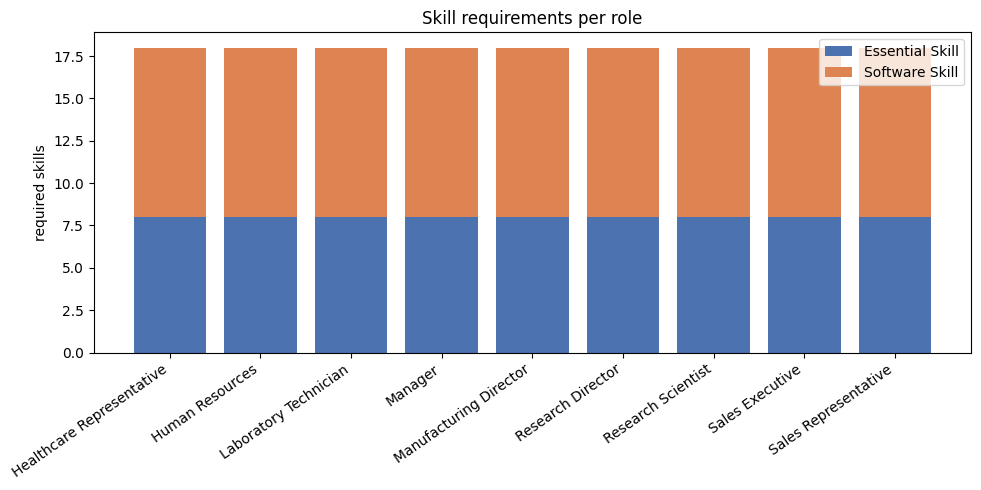

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bottom = None
for column, colour in [("Essential Skill", "#4C72B0"), ("Software Skill", "#DD8452")]:
    if column in skill_profile.columns:
        ax.bar(skill_profile.index, skill_profile[column], bottom=bottom,
               label=column, color=colour)
        bottom = skill_profile[column] if bottom is None else bottom + skill_profile[column]
ax.set(ylabel="required skills", title="Skill requirements per role")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## A single role in full

In [8]:
role = "Research Scientist"
print(f"=== {role} ===")
print(requirements[requirements["JobRole"] == role]
      .sort_values(["SkillType", "RankInRole"])[["SkillType", "SkillName", "Importance"]]
      .to_string(index=False))

=== Research Scientist ===
      SkillType             SkillName  Importance
Essential Skill               Writing        4.25
Essential Skill              Speaking        4.12
Essential Skill               Science        4.12
Essential Skill       Active Learning        4.12
Essential Skill      Active Listening        4.00
Essential Skill Reading Comprehension        4.00
Essential Skill     Critical Thinking        4.00
Essential Skill           Mathematics        3.62
 Software Skill      Microsoft Office        4.50
 Software Skill       Microsoft Excel        4.50
 Software Skill                     R        4.50
 Software Skill           ESRI ArcGIS        3.50
 Software Skill       Adobe Photoshop        3.50
 Software Skill                MATLAB        3.50
 Software Skill                   SAS        3.50
 Software Skill                Python        3.50
 Software Skill   IBM SPSS Statistics        3.50
 Software Skill     Microsoft Project        3.50


## Which skills are demanded by the most roles

A skill required across many roles is a stronger candidate for centralised training
than one needed by a single team.

In [9]:
breadth = (requirements.groupby("SkillName")
           .agg(RolesRequiring=("JobRole", "nunique"), AvgImportance=("Importance", "mean"))
           .round(2)
           .sort_values(["RolesRequiring", "AvgImportance"], ascending=False))
breadth.head(15)

,RolesRequiring,AvgImportance
SkillName,,
Microsoft Excel,9,4.50
Microsoft Office,9,4.50
Active Listening,9,3.94
Speaking,9,3.93
Reading Comprehension,9,3.82
Critical Thinking,9,3.70
Writing,9,3.54
Active Learning,9,3.46
Monitoring,8,3.42


The ten essential skills are required by all nine roles - unsurprising, since O*NET
rates every occupation on the same skill inventory. The software requirements are
what actually differentiate roles, and they are where the interesting gaps appear in
notebook 13.

In [10]:
role_master.to_csv(PROCESSED_FILES["occupation"].parent / "role_master.csv", index=False)
print("written: role_master.csv")

written: role_master.csv
